In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from transformers import AutoTokenizer

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_parquet("/Users/YGT/ist-airport-decision-support-system/data/model/splits/full_df_clean.parquet")

# Embedding Dimension Control 

In [18]:
import numpy as np

def get_first_emb_dim(x):
    if x is None:
        return None
    if len(x) == 0:
        return None
    
    first = x[0]
    if first is None:
        return None
    
    first = np.asarray(first)
    if first.ndim == 0:
        return None
    return len(first)

focusing_dims = set()
active_dims = set()
prior_dims = set()

for _, row in df.iterrows():
    f = row["focusing_emb"]
    if f is not None and len(f) > 0:
        focusing_dims.add(len(np.asarray(f)))

    a_dim = get_first_emb_dim(row["active_embs"])
    if a_dim is not None:
        active_dims.add(a_dim)

    p_dim = get_first_emb_dim(row["prior_embs"])
    if p_dim is not None:
        prior_dims.add(p_dim)

print("focusing_dims:", focusing_dims)
print("active_dims:", active_dims)
print("prior_dims:", prior_dims)

focusing_dims: {256}
active_dims: {256}
prior_dims: {256}


In [19]:
df.columns

Index(['hex_icao', 'airline_name_english', 'callsign_code_iata',
       'callsign_code_icao', 'haul', 'dep_code_iata', 'dep_code_icao',
       'dep_name_english', 'dep_lat', 'dep_lon', 'dep_altitude',
       'dest_code_iata', 'dest_code_icao', 'dest_name_english', 'dest_lat',
       'dest_lon', 'dest_altitude', 'distance', 'actual_entry_time',
       'arr_sched_time_utc', 'date', 'day_of_week', 'aircraft_type',
       'aircraft_registration', 'wake_turbulence_cat',
       'post_terminal_duration_min', 'weather_prompt', 'scenario_id',
       'focusing_flight_id', 'entry_time', 'obs_time', 'scen_idx',
       'focusing_emb', 'active_embs', 'prior_embs', 'active_flight_ids',
       'prior_flight_ids', 'n_active', 'n_prior', 'label_post_terminal_s',
       'label_post_terminal_min'],
      dtype='str')

In [28]:
df[['n_active', 'n_prior']].describe(np.arange(0,1,0.05)).T

,count,mean,std,min,0%,5%,10%,15%,20%,25%,30%,35%,40%,45%,50%,55%,60%,65%,70%,75%,80%,85%,90%,95%,max
n_active,154415.0,12.880776,5.907371,0.0,0.0,4.0,5.0,6.0,8.0,8.0,9.0,10.0,11.0,12.0,13.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,21.0,23.0,38.0
n_prior,154415.0,12.057022,5.823335,0.0,0.0,3.0,5.0,6.0,7.0,8.0,9.0,9.0,10.0,11.0,12.0,13.0,13.0,14.0,15.0,16.0,17.0,18.0,20.0,22.0,37.0


# Prompt Lenght Analysis

In [29]:
def safe(x):
    try:
        if pd.isna(x):
            return "could not be clearly identified"
    except Exception:
        pass
    return x

In [30]:
def flt_plan_prompt_v1(flight_df: pd.Series):
    prompt = (
        f"Current time: {safe(flight_df['obs_time'])}. "
        f"Actual airspace entry time for flight {safe(flight_df['callsign_code_icao'])} "
        f"was {safe(flight_df['actual_entry_time'])}. "
        f"This {safe(flight_df['haul'])} flight operated by {safe(flight_df['airline_name_english'])} "
        f"was scheduled to arrive at {safe(flight_df['arr_sched_time_utc'])} UTC on "
        f"{safe(flight_df['date'])} ({safe(flight_df['day_of_week'])}). "
        f"It originated from {safe(flight_df['dep_name_english'])} "
        f"({safe(flight_df['dep_code_icao'])} / {safe(flight_df['dep_code_iata'])}, "
        f"lat: {safe(flight_df['dep_lat'])}, lon: {safe(flight_df['dep_lon'])}, "
        f"alt: {safe(flight_df['dep_altitude'])} ft) "
        f"and was headed for Istanbul Airport "
        f"({safe(flight_df['dest_code_icao'])} / {safe(flight_df['dest_code_iata'])}, "
        f"lat: {safe(flight_df['dest_lat'])}, lon: {safe(flight_df['dest_lon'])}, "
        f"alt: {safe(flight_df['dest_altitude'])} ft). "
        f"The Aircraft type: {safe(flight_df['aircraft_type'])}. "
        f"Registration number: {safe(flight_df['aircraft_registration'])}. "
        f"Wake turbulence category: {safe(flight_df['wake_turbulence_cat'])}. "
        f"Total route distance: {safe(flight_df['distance'])} km."
    )
    return prompt

In [32]:
def flt_plan_prompt_v2(flight_df: pd.Series):
    prompt = (
        f"Scheduled for arrival at {safe(flight_df['arr_sched_time_utc'])} UTC on "
        f"{safe(flight_df['date'])} ({safe(flight_df['day_of_week'])}), "
        f"flight {safe(flight_df['callsign_code_iata'])}/"
        f"{safe(flight_df['callsign_code_icao'])} by {safe(flight_df['airline_name_english'])} "
        f"was set to land at {safe(flight_df['dest_name_english'])} "
        f"({safe(flight_df['dest_code_iata'])}/{safe(flight_df['dest_code_icao'])}, "
        f"lat: {safe(flight_df['dest_lat'])}, lon: {safe(flight_df['dest_lon'])}, "
        f"alt: {safe(flight_df['dest_altitude'])} ft). "
        f"The aircraft originated from {safe(flight_df['dep_name_english'])} "
        f"({safe(flight_df['dep_code_iata'])}/{safe(flight_df['dep_code_icao'])}, "
        f"lat: {safe(flight_df['dep_lat'])}, lon: {safe(flight_df['dep_lon'])}, "
        f"alt: {safe(flight_df['dep_altitude'])} ft), "
        f"and the total route spanned {safe(flight_df['distance'])} km. "
        f"The aircraft was a {safe(flight_df['aircraft_type'])} with registration "
        f"{safe(flight_df['aircraft_registration'])}, and it belonged to the "
        f"{safe(flight_df['wake_turbulence_cat'])} wake turbulence category. "
        f"It was expected to enter airspace or appear via ADS-B at "
        f"{safe(flight_df['actual_entry_time'])}. "
        f"This was a {safe(flight_df['haul'])}-haul flight."
    )
    return prompt

In [31]:
def weather_prompt(row: pd.Series):
    return row["weather_prompt"]

In [ ]:
def build_prompt(row: pd.Series, use_weather: bool = True):
    base_prompt = random.choice([
        flt_plan_prompt_v1(row),
        flt_plan_prompt_v2(row),
    ])

    parts = [base_prompt]

    if use_weather:
        wp = row.get("weather_prompt", "")
        if isinstance(wp, str) and wp.strip():
            parts.append(wp.strip())

    return "\n\n".join(parts)

In [36]:
TRAJ_PROMPT_1 = "Airspace is described using three trajectory types. This embedding is for the focus trajectory: {"
TRAJ_PROMPT_2 = "} These embeddings are for other active trajectories: {"
TRAJ_PROMPT_3 = "} These embeddings are for past or inactive trajectories that may still matter: {"
TRAJ_PROMPT_4 = "} Missing types will have no embedding. Based on the above, predict the total time spent in the airspace."

In [38]:
def build_prompt_v1_for_eda(row: pd.Series, use_weather: bool = True):
    parts = [flt_plan_prompt_v1(row)]

    if use_weather:
        wp = row.get("weather_prompt", "")
        if isinstance(wp, str) and wp.strip():
            parts.append(wp.strip())

    return "\n\n".join(parts)


def build_prompt_v2_for_eda(row: pd.Series, use_weather: bool = True):
    parts = [flt_plan_prompt_v2(row)]

    if use_weather:
        wp = row.get("weather_prompt", "")
        if isinstance(wp, str) and wp.strip():
            parts.append(wp.strip())

    return "\n\n".join(parts)

In [39]:
df["prompt_v1"] = df.apply(
    lambda row: build_prompt_v1_for_eda(row, use_weather=True),
    axis=1
)

df["prompt_v2"] = df.apply(
    lambda row: build_prompt_v2_for_eda(row, use_weather=True),
    axis=1
)

In [44]:
print("pad_token:", tokenizer.pad_token)
print("pad_token_id:", tokenizer.pad_token_id)

print("eos_token:", tokenizer.eos_token)
print("eos_token_id:", tokenizer.eos_token_id)

print("bos_token:", tokenizer.bos_token)
print("bos_token_id:", tokenizer.bos_token_id)

pad_token: <|endoftext|>
pad_token_id: 151643
eos_token: <|im_end|>
eos_token_id: 151645
bos_token: None
bos_token_id: None


In [45]:
tokenizer.padding_side 

'right'

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [46]:
enc_v1 = tokenizer(
    df["prompt_v1"].tolist(),
    add_special_tokens=True,
    truncation=False,
    padding=False
)

df["prompt_v1_len"] = [len(x) for x in enc_v1["input_ids"]] 

In [47]:
enc_v2 = tokenizer(
    df["prompt_v2"].tolist(),
    add_special_tokens=True,
    truncation=False,
    padding=False
)

df["prompt_v2_len"] = [len(x) for x in enc_v2["input_ids"]]

In [70]:
enc_weather = tokenizer( 
    df["weather_prompt"].to_list(), 
    add_special_tokens=True, 
    truncation=False, 
    padding=False
) 

df["enc_weather_prompt"] = [len(x) for x in enc_weather["input_ids"]]

In [71]:
print("WEATHER TOKEN LENGTH")
print(df["enc_weather_prompt"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

WEATHER TOKEN LENGTH
count    154415.000000
mean        149.012823
std          35.058781
min          67.000000
50%         132.000000
90%         197.000000
95%         205.000000
99%         226.000000
max         273.000000
Name: enc_weather_prompt, dtype: float64


In [48]:
print("V1 TOKEN LENGTH")
print(df["prompt_v1_len"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print()

print("V2 TOKEN LENGTH")
print(df["prompt_v2_len"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

V1 TOKEN LENGTH
count    154415.000000
mean        421.139138
std          35.533675
min         338.000000
50%         406.000000
90%         469.000000
95%         479.000000
99%         499.860000
max         555.000000
Name: prompt_v1_len, dtype: float64

V2 TOKEN LENGTH
count    154415.000000
mean        411.140336
std          35.524486
min         328.000000
50%         396.000000
90%         459.000000
95%         469.000000
99%         490.000000
max         546.000000
Name: prompt_v2_len, dtype: float64


In [51]:
traj_segments = [
    TRAJ_PROMPT_1,
    TRAJ_PROMPT_2,
    TRAJ_PROMPT_3,
    TRAJ_PROMPT_4,
]

traj_prompt_token_cost = sum(
    len(tokenizer(seg, add_special_tokens=False)["input_ids"])
    for seg in traj_segments
)

print("Static trajectory prompt token cost:", traj_prompt_token_cost)

Static trajectory prompt token cost: 65


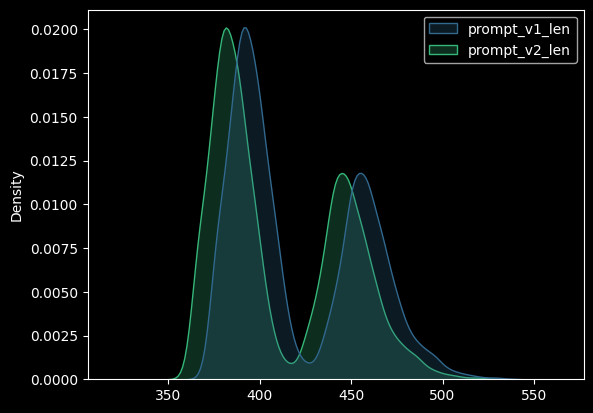

In [ ]:
import matplotlib.pyplot as plt, seaborn as sns
plt.style.use('dark_background')
sns.kdeplot(data=df[['prompt_v1_len', 'prompt_v2_len']], fill=True, palette='viridis', common_norm=False)
plt.show()

In [62]:
print("N_ACTIVE")
print(
    df["n_active"].describe(
        percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nN_PRIOR")
print(
    df["n_prior"].describe(
        percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

N_ACTIVE
count    154415.000000
mean         12.880776
std           5.907371
min           0.000000
5%            4.000000
10%           5.000000
25%           8.000000
50%          13.000000
75%          17.000000
90%          21.000000
95%          23.000000
99%          28.000000
max          38.000000
Name: n_active, dtype: float64

N_PRIOR
count    154415.000000
mean         12.057022
std           5.823335
min           0.000000
5%            3.000000
10%           5.000000
25%           8.000000
50%          12.000000
75%          16.000000
90%          20.000000
95%          22.000000
99%          26.000000
max          37.000000
Name: n_prior, dtype: float64


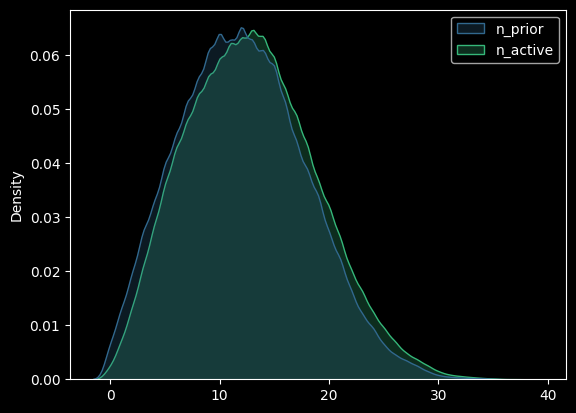

In [64]:
plt.style.use('dark_background')
sns.kdeplot(data=df[['n_prior', 'n_active']], fill=True, palette='viridis', common_norm=False)
plt.show()

# Target Dist.

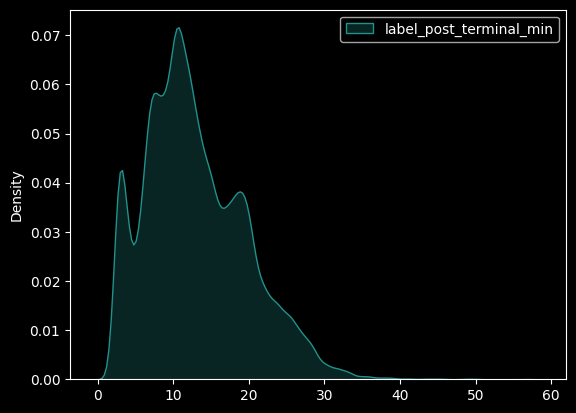

In [68]:
plt.style.use('dark_background')
sns.kdeplot(data=df[["label_post_terminal_min"]], fill=True, palette='viridis', common_norm=False)
plt.show()

In [69]:
df["label_post_terminal_min"].describe(np.arange(0,1,0.05))

count    154415.000000
mean         12.921317
std           6.689678
min           1.183333
0%            1.183333
5%            3.150000
10%           4.600000
15%           6.250000
20%           7.150000
25%           8.000000
30%           8.866667
35%           9.733333
40%          10.416667
45%          11.083333
50%          11.833333
55%          12.650000
60%          13.583333
65%          14.683333
70%          15.933333
75%          17.366667
80%          18.716667
85%          20.033333
90%          22.083333
95%          25.316667
max          57.150000
Name: label_post_terminal_min, dtype: float64

In [72]:
480 + 225 + 65

770